# Bank statement debit transactions: where do the models diverge?

Bank statements are the only document type this corpus still discriminates on -- invoices and
receipts are saturated at median F1 1.000 for both models. The gap is large and already
measured. The open question is **WHERE in the transaction list the two models diverge**:

* concentrated at high positions -> tail-drop / attention decay over a long table
* spread evenly -> per-row reading accuracy

Those have different causes and different fixes.

**Method** (adapted from cells 15-18 of `evaluation_visualiser.ipynb`, parameterised by model).
For every statement we walk the three parallel debit register columns position by position and
classify each index as:

| Outcome | Meaning |
|---|---|
| **match** | extracted value at position *i* matches ground truth |
| **wrong** | a value is present but does not match |
| **miss** | ground truth has a value here, the extraction does not -- truncation |
| **extra** | the extraction has a value, ground truth does not -- over-extraction |

Results are pooled across all 55 statements, so position *n* aggregates the *n*th debit from
every document.

**Credit rows are dropped from both sides first**, exactly as the scorer does, so position *n*
means the *n*th DEBIT for both models and the indices are directly comparable. The per-item
comparison mirrors the scorer too: semantic monetary/date matching for the transaction fields,
Jaccard fuzzy matching for `LINE_ITEM_DESCRIPTIONS` (which is NOT in `transaction_list_fields`
and so does NOT get exact-match treatment).

In [1]:
import json
import os
import sys
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display


def repo_root() -> Path:
    """Find the LMM_POC checkout by walking up from the working directory.

    Jupyter sets the kernel's cwd to the notebook's own directory, so
    `import common` fails unless whoever launched the kernel exported
    PYTHONPATH -- which nbconvert does and an IDE generally does not. Locate
    the checkout by a file known to live in it rather than depend on the
    launcher.
    """
    for directory in (Path.cwd(), *Path.cwd().parents):
        if (directory / "common" / "evaluation_metrics.py").is_file():
            return directory
    raise ModuleNotFoundError(
        f"Could not find the LMM_POC checkout from {Path.cwd()}.\n"
        "  Expected: this notebook to sit inside the repository, so that some "
        "parent directory contains common/evaluation_metrics.py.\n"
        "  Fix: open the notebook from within the repo (notebooks/ is fine), or "
        "start the kernel with PYTHONPATH=/path/to/LMM_POC."
    )


REPO_ROOT = repo_root()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from common.evaluation_metrics import _fuzzy_text_match, _transaction_item_matches  # noqa: E402
from common.extraction_evaluator import _drop_credit_rows, _normalize_transaction_order  # noqa: E402
from common.field_schema import get_field_schema  # noqa: E402

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update(
    {
        "figure.dpi": 120,
        "font.size": 11,
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "svg.fonttype": "path",
    }
)

# Same validated palette as degradation_comparison.ipynb: CVD separation
# dE 20.0 (protan), normal-vision dE 26.9. Colour follows the ENTITY.
INTERNVL = "#4C72B0"
GEMMA = "#DD8452"
MODEL_COLOUR = {"InternVL3.5-8B": INTERNVL, "Gemma 4 12B W4A16": GEMMA}
MODELS = list(MODEL_COLOUR)
INK = "#2b2b2b"

# Where the output_* run directories live. LMM_EVAL_ROOT overrides outright.
# With nothing set, try the sandbox tree then a local download -- hard-coding a
# Mac path breaks this notebook on the box, and hard-coding the box path is what
# forced the override locally. Same resolution as degradation_comparison.ipynb;
# the chosen root is printed, so it is never silent.
SANDBOX_ROOT = Path("/home/jovyan/nfs_share/tod_2026/evaluation_data")
LOCAL_ROOT = Path.home() / "Downloads"
SENTINEL = "output_gemma_synthetic"  # any one run dir identifies a results tree


def locate_root() -> Path:
    """Resolve the results root, failing with a diagnostic rather than a stack trace."""
    override = os.environ.get("LMM_EVAL_ROOT")
    if override:
        root = Path(override)
        if (root / SENTINEL).is_dir():
            return root
        raise FileNotFoundError(
            f"LMM_EVAL_ROOT is set to '{root}' but there is no {SENTINEL}/ inside it.\n"
            f"  Expected: a directory holding output_internvl_synthetic and "
            f"output_gemma_synthetic.\n"
            f"  Fix: point LMM_EVAL_ROOT at that directory, or unset it to try "
            f"{SANDBOX_ROOT} then {LOCAL_ROOT}."
        )
    for candidate in (SANDBOX_ROOT, LOCAL_ROOT):
        if (candidate / SENTINEL).is_dir():
            return candidate
    raise FileNotFoundError(
        f"No results tree found: neither {SANDBOX_ROOT} nor {LOCAL_ROOT} "
        f"contains {SENTINEL}/.\n"
        f"  Expected: a directory holding output_internvl_synthetic and "
        f"output_gemma_synthetic.\n"
        f"  Fix: set LMM_EVAL_ROOT to wherever the downloaded results are, "
        f"e.g. LMM_EVAL_ROOT=$HOME/Downloads."
    )


ROOT = locate_root()


def locate_ground_truth() -> Path:
    """Find ground_truth.jsonl without hard-coding a dataset directory name.

    The previous default pointed at a specific dataset directory
    (synthetic_20260811/), which broke the notebook the moment results were
    read from anywhere else -- the corpus is regenerated under a new date and
    downloaded copies sit flat. Search instead, in order of specificity, and
    let LMM_GT_PATH override outright.
    """
    override = os.environ.get("LMM_GT_PATH")
    if override:
        path = Path(override)
        if path.is_file():
            return path
        raise FileNotFoundError(
            f"LMM_GT_PATH is set to '{path}' but there is no file there.\n"
            f"  Expected: a JSONL file, one ground-truth record per line.\n"
            f"  Fix: correct LMM_GT_PATH, or unset it to search under {ROOT}."
        )

    candidates = [
        ROOT / "ground_truth.jsonl",  # flat, e.g. a copy downloaded to ~/Downloads
        *sorted(ROOT.glob("synthetic_*/ground_truth.jsonl")),  # dataset dir, newest name last
        *sorted(ROOT.glob("*/ground_truth.jsonl")),  # any other dataset dir
    ]
    for candidate in candidates:
        if candidate.is_file():
            return candidate

    checked = "\n            ".join(str(c) for c in candidates) or "(none -- ROOT does not exist?)"
    raise FileNotFoundError(
        f"No ground_truth.jsonl found under {ROOT}.\n"
        f"  Checked: {checked}\n"
        f"  Expected: {ROOT / 'ground_truth.jsonl'}, or "
        f"{ROOT / '<dataset>' / 'ground_truth.jsonl'}.\n"
        f"  Fix: set LMM_EVAL_ROOT to the directory holding the output_* run "
        f"directories, or set LMM_GT_PATH to the ground-truth file directly."
    )


GT_PATH = locate_ground_truth()

print(f"repo root:    {REPO_ROOT}")
print(f"results root: {ROOT}")
print(f"ground truth: {GT_PATH}")

RUNS = {
    "InternVL3.5-8B": ROOT / "output_internvl_synthetic",
    "Gemma 4 12B W4A16": ROOT / "output_gemma_synthetic",
}

# The three parallel columns of the debit register.
FIELDS = ["TRANSACTION_AMOUNTS_PAID", "TRANSACTION_DATES", "LINE_ITEM_DESCRIPTIONS"]
TXN_FIELDS = get_field_schema().transaction_list_fields

repo root:    /Users/tod/Desktop/LMM_POC
results root: /Users/tod/Downloads
ground truth: /Users/tod/Downloads/ground_truth.jsonl


In [2]:
def locate(out_dir: Path, filename: str) -> Path:
    """Accept either <out>/evaluation/<f> or a flattened <out>/<f>."""
    for candidate in (out_dir / "evaluation" / filename, out_dir / filename):
        if candidate.exists():
            return candidate
    raise FileNotFoundError(f"{filename} not found under {out_dir} (checked ./ and ./evaluation/)")


def read_jsonl(path: Path) -> list[dict]:
    with path.open() as handle:
        return [json.loads(line) for line in handle if line.strip()]


def split_items(value: str) -> list[str]:
    """Pipe-separated list -> items, with NOT_FOUND meaning an empty list."""
    text = str(value).strip()
    if text.upper() == "NOT_FOUND":
        return []
    return [item.strip() for item in text.split("|") if item.strip()]


def item_matches(extracted: str, truth: str, field: str) -> bool:
    """Mirror the scorer's per-item comparison.

    Transaction fields get semantic monetary/date comparison. Everything else
    -- notably LINE_ITEM_DESCRIPTIONS -- gets Jaccard word-overlap matching.
    Using exact match here would understate descriptions substantially.
    """
    if field in TXN_FIELDS:
        return _transaction_item_matches(extracted, truth, field)
    return _fuzzy_text_match(extracted, truth)


ground_truth = {
    (r.get("filename") or r.get("image_name")): r
    for r in read_jsonl(GT_PATH)
    if r.get("DOCUMENT_TYPE") == "BANK_STATEMENT"
}
print(f"bank statements in ground truth: {len(ground_truth)}")

bank statements in ground truth: 55


In [3]:
outcomes: dict[str, dict] = {}
row_counts: list[dict] = []

for model, out_dir in RUNS.items():
    extractions = {
        r["image_name"]: r
        for r in read_jsonl(locate(out_dir, "cleaned_extractions.jsonl"))
        if r.get("document_type") == "BANK_STATEMENT"
    }

    per_field = defaultdict(lambda: defaultdict(lambda: {"match": 0, "wrong": 0, "miss": 0, "extra": 0}))

    for name, truth_raw in ground_truth.items():
        record = extractions.get(name)
        if not record:
            continue

        # Exactly the scorer's normalisation: drop credit rows from BOTH sides,
        # then sort chronologically, before comparing anything positionally.
        extracted = _normalize_transaction_order(
            _drop_credit_rows(record.get("extracted_data", {}), "BANK_STATEMENT"), "BANK_STATEMENT"
        )
        truth = _normalize_transaction_order(
            _drop_credit_rows(dict(truth_raw), "BANK_STATEMENT"), "BANK_STATEMENT"
        )

        row_counts.append(
            {
                "model": model,
                "image": name,
                "gt_rows": len(split_items(truth.get("TRANSACTION_AMOUNTS_PAID", ""))),
                "extracted_rows": len(split_items(extracted.get("TRANSACTION_AMOUNTS_PAID", ""))),
            }
        )

        for field in FIELDS:
            got, want = split_items(extracted.get(field, "")), split_items(truth.get(field, ""))
            for index in range(max(len(got), len(want))):
                left = got[index] if index < len(got) else ""
                right = want[index] if index < len(want) else ""
                bucket = per_field[field][index + 1]
                if not left and right:
                    bucket["miss"] += 1
                elif left and not right:
                    bucket["extra"] += 1
                elif item_matches(left, right, field):
                    bucket["match"] += 1
                else:
                    bucket["wrong"] += 1

    outcomes[model] = per_field

rows = pd.DataFrame(row_counts)
rows["delta"] = rows["extracted_rows"] - rows["gt_rows"]
print(f"statements compared: {len(rows) // len(MODELS)} per model")

statements compared: 55 per model


## Does either model get the number of transactions right?

Before asking *which* rows are wrong, ask whether the list is even the right length. A short
list means truncation; a long one means over-extraction. Either destroys positional alignment
for everything after the error.

In [4]:
summary = (
    rows.assign(
        outcome=np.select([rows["delta"] < 0, rows["delta"] == 0], ["short", "exact"], default="over")
    )
    .groupby(["model", "outcome"], observed=True)
    .size()
    .unstack(fill_value=0)
    .reindex(columns=["short", "exact", "over"], fill_value=0)
)
summary["gt_rows"] = rows.groupby("model")["gt_rows"].sum()
summary["extracted_rows"] = rows.groupby("model")["extracted_rows"].sum()
summary["mean_delta"] = rows.groupby("model")["delta"].mean().round(2)
display(summary)

outcome,short,exact,over,gt_rows,extracted_rows,mean_delta
model,,,,,,
Gemma 4 12B W4A16,3,44,8,1223,1232,0.16
InternVL3.5-8B,19,9,27,1223,1239,0.29


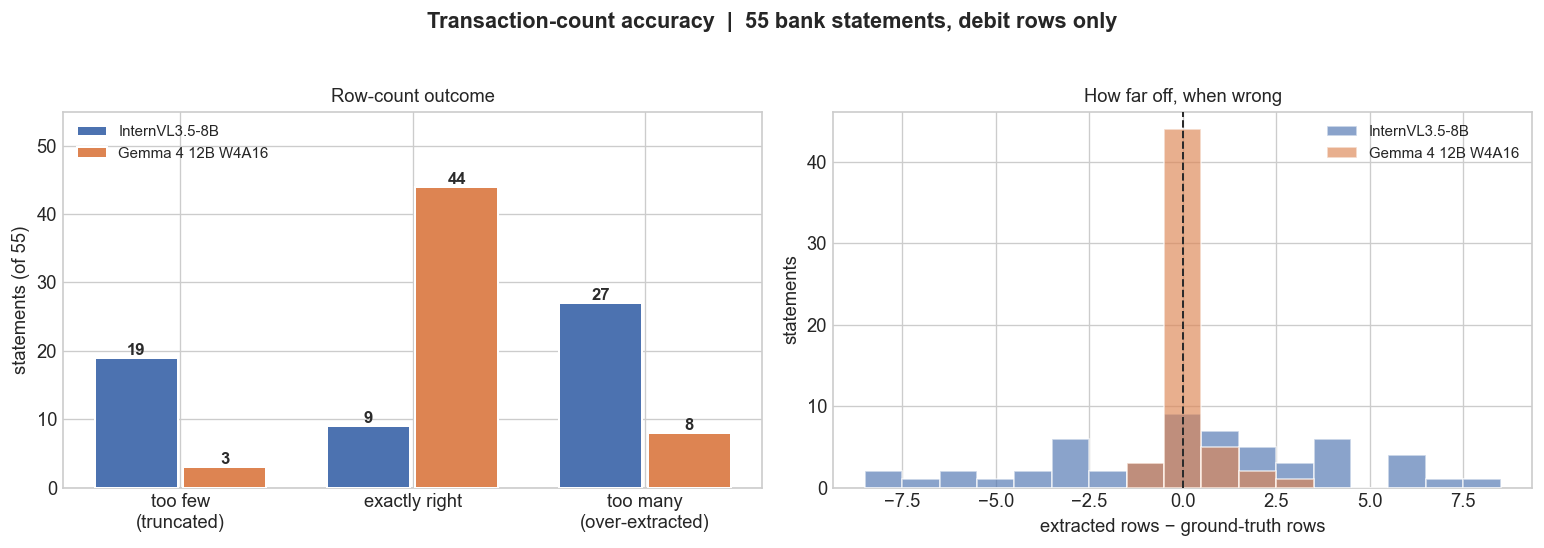

In [5]:
fig_rows, axes = plt.subplots(1, 2, figsize=(13, 4.4))
fig_rows.suptitle(
    "Transaction-count accuracy  |  55 bank statements, debit rows only",
    fontsize=13,
    fontweight="bold",
    y=1.03,
)

# --- Panel 1: how often is the row count exactly right? --------------------- #
ax = axes[0]
categories = ["short", "exact", "over"]
x = np.arange(len(categories))
width = 0.38
for offset, model in zip((-width / 2, width / 2), MODELS):
    values = [summary.loc[model, c] for c in categories]
    bars = ax.bar(
        x + offset,
        values,
        width=width * 0.94,
        color=MODEL_COLOUR[model],
        label=model,
        edgecolor="white",
        linewidth=1.2,
        zorder=3,
    )
    for bar, value in zip(bars, values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            str(value),
            ha="center",
            va="bottom",
            fontsize=10,
            fontweight="bold",
            color=INK,
        )
ax.set_xticks(x, ["too few\n(truncated)", "exactly right", "too many\n(over-extracted)"])
ax.set_ylabel("statements (of 55)")
ax.set_title("Row-count outcome", fontsize=11)
ax.set_ylim(0, 55)
ax.legend(frameon=False, loc="upper left", fontsize=9)

# --- Panel 2: distribution of the miscount ---------------------------------- #
ax = axes[1]
bins = np.arange(rows["delta"].min() - 0.5, rows["delta"].max() + 1.5, 1)
for model in MODELS:
    ax.hist(
        rows.loc[rows["model"] == model, "delta"],
        bins=bins,
        alpha=0.65,
        color=MODEL_COLOUR[model],
        label=model,
        edgecolor="white",
        zorder=3,
    )
ax.axvline(0, color=INK, linestyle="--", linewidth=1.2, zorder=4)
ax.set_xlabel("extracted rows − ground-truth rows")
ax.set_ylabel("statements")
ax.set_title("How far off, when wrong", fontsize=11)
ax.legend(frameon=False, fontsize=9)

plt.tight_layout()
plt.show()

## Match rate by position

One panel per register column. If the lines fall as position increases, accuracy decays along
the table -- the attention-decay hypothesis. If they are flat, the deficit is per-row reading
accuracy and position is irrelevant.

Positions with fewer than 5 observations are dropped: the tail of the longest statements is
thin, and a single document should not swing a point.

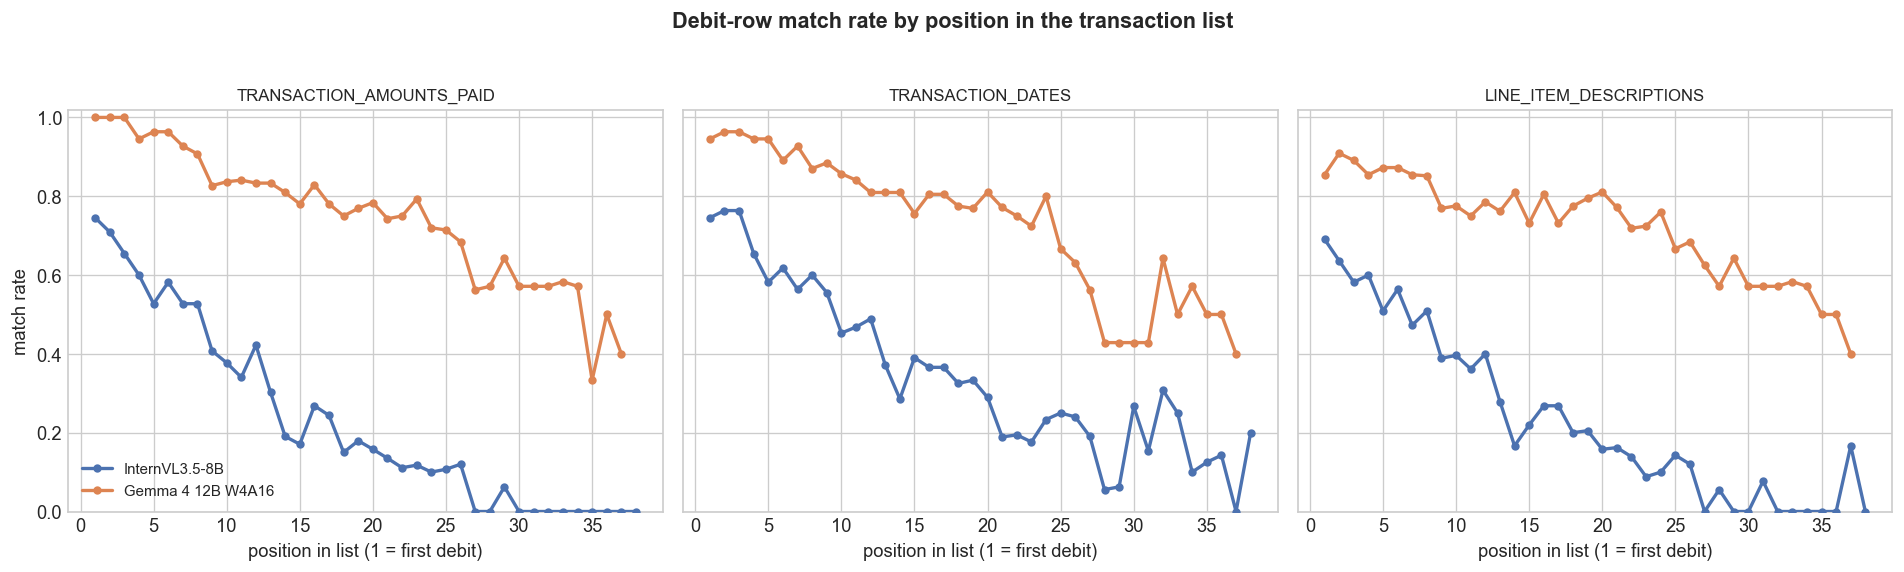

pearson_r  positions  \
field                    model                                     
TRANSACTION_AMOUNTS_PAID InternVL3.5-8B        -0.944         38   
                         Gemma 4 12B W4A16     -0.957         37   
TRANSACTION_DATES        InternVL3.5-8B        -0.912         38   
                         Gemma 4 12B W4A16     -0.926         37   
LINE_ITEM_DESCRIPTIONS   InternVL3.5-8B        -0.935         38   
                         Gemma 4 12B W4A16     -0.928         37   

                                            first_pos_rate  
field                    model                              
TRANSACTION_AMOUNTS_PAID InternVL3.5-8B              0.745  
                         Gemma 4 12B W4A16           1.000  
TRANSACTION_DATES        InternVL3.5-8B              0.745  
                         Gemma 4 12B W4A16           0.945  
LINE_ITEM_DESCRIPTIONS   InternVL3.5-8B              0.691  
                         Gemma 4 12B W4A16           0.855

In [6]:
MIN_OBS = 5


def rate_series(model: str, field: str) -> pd.DataFrame:
    records = []
    for position, counts in sorted(outcomes[model][field].items()):
        total = sum(counts.values())
        if total < MIN_OBS:
            continue
        records.append(
            {
                "position": position,
                "n": total,
                "match_rate": counts["match"] / total,
                "miss_rate": counts["miss"] / total,
            }
        )
    return pd.DataFrame(records)


fig_pos, axes = plt.subplots(1, 3, figsize=(16, 4.6), sharey=True)
fig_pos.suptitle(
    "Debit-row match rate by position in the transaction list",
    fontsize=13,
    fontweight="bold",
    y=1.03,
)

correlations = []
for ax, field in zip(axes, FIELDS):
    for model in MODELS:
        series = rate_series(model, field)
        ax.plot(
            series["position"],
            series["match_rate"],
            marker="o",
            markersize=4,
            linewidth=2,
            color=MODEL_COLOUR[model],
            label=model,
            zorder=3,
        )
        r = float(np.corrcoef(series["position"], series["match_rate"])[0, 1])
        correlations.append(
            {
                "field": field,
                "model": model,
                "pearson_r": round(r, 3),
                "positions": len(series),
                "first_pos_rate": round(series["match_rate"].iloc[0], 3),
            }
        )
    ax.set_title(field, fontsize=10)
    ax.set_xlabel("position in list (1 = first debit)")
    ax.set_ylim(0, 1.02)
axes[0].set_ylabel("match rate")
axes[0].legend(frameon=False, loc="lower left", fontsize=9)
plt.tight_layout()
plt.show()

display(pd.DataFrame(correlations).set_index(["field", "model"]))

## Truncation *within* the list

`miss` counts positions where ground truth has a value and the extraction simply stops. It is
a different failure from reading a row wrongly, and it compounds: everything after a dropped
row is misaligned.

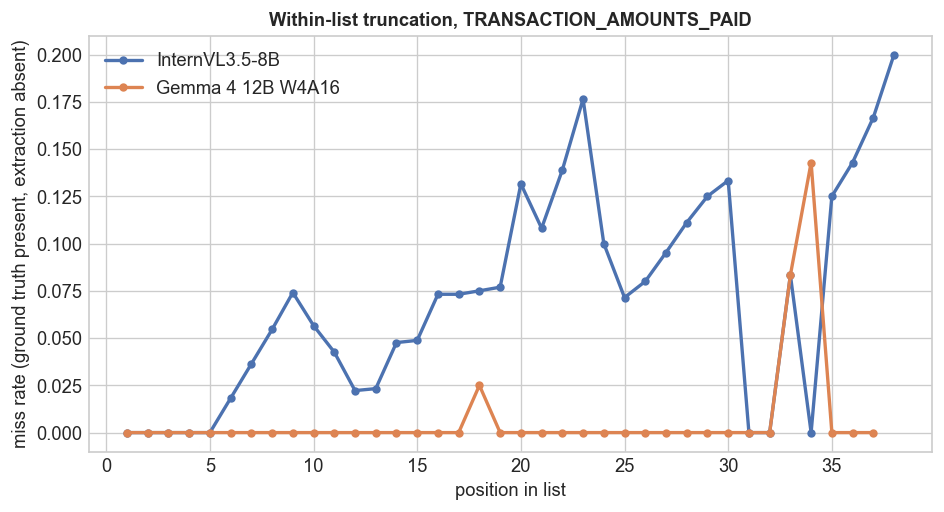

In [7]:
fig_miss, ax = plt.subplots(figsize=(8, 4.4))
for model in MODELS:
    series = rate_series(model, "TRANSACTION_AMOUNTS_PAID")
    ax.plot(
        series["position"],
        series["miss_rate"],
        marker="o",
        markersize=4,
        linewidth=2,
        color=MODEL_COLOUR[model],
        label=model,
        zorder=3,
    )
ax.set_xlabel("position in list")
ax.set_ylabel("miss rate (ground truth present, extraction absent)")
ax.set_title("Within-list truncation, TRANSACTION_AMOUNTS_PAID", fontsize=11, fontweight="bold")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

In [8]:
FIG_DIR = Path(os.environ.get("LMM_FIG_DIR", "figures"))
FIG_DIR.mkdir(parents=True, exist_ok=True)
for name, figure in (
    ("debit_row_counts", fig_rows),
    ("debit_match_by_position", fig_pos),
    ("debit_truncation", fig_miss),
):
    for extension in ("svg", "png"):
        path = FIG_DIR / f"{name}.{extension}"
        figure.savefig(path, format=extension, bbox_inches="tight", dpi=200)
        print(f"wrote {path}")

wrote figures/debit_row_counts.svg
wrote figures/debit_row_counts.png
wrote figures/debit_match_by_position.svg


wrote figures/debit_match_by_position.png
wrote figures/debit_truncation.svg
wrote figures/debit_truncation.png


## Findings

_Written from the 2026-08-12 single-commit provenance run. The figures above compute
themselves; this section is the only hand-written part._

**1. Tail-drop is real, steep, and affects BOTH models.** Pearson *r* between position and
match rate runs from -0.73 to -0.96 across the three columns. Gemma is not immune: on amounts
and dates its correlation is as strong as InternVL's. Accuracy decays along the table for
both, which is the attention-decay pattern already diagnosed on the transaction-linking side.

**2. Gemma is ahead at every position, and from a much higher base.** On
`TRANSACTION_AMOUNTS_PAID` it reads the first three debits perfectly (100%) against InternVL's
74/71/66%. By position 15 the gap is 78% vs 17%; by position 30, 57% vs 0%.

**3. The sharpest differentiator is the row count, not the reading.** Gemma gets the number of
debit rows exactly right in 44 of 55 statements; InternVL in 9. InternVL is short on 19 and
over-extracts on 27 -- it agrees with the ground truth on how many transactions exist in only
16% of documents. Every row after a miscount is positionally misaligned, so this alone
explains much of the per-position gap.

**4. Only InternVL truncates within the list.** Gemma's miss rate is zero at every position:
when it emits a list, the list is the right length and no position is empty. InternVL drops
values mid-list from position 6 onward.

**5. Descriptions are the weakest column for both**, but that is partly the metric.
`LINE_ITEM_DESCRIPTIONS` is not in `transaction_list_fields`, so it is scored by Jaccard word
overlap at a 0.75 threshold rather than semantic comparison -- stricter than the monetary
comparison that lets amounts reach 100%. Worth revisiting given that exactly this class of
strictness produced the `BUSINESS_ADDRESS` artefact.

## What this does NOT say

The correlation is between position and accuracy, not proof of a causal attention mechanism.
Later rows are also further down the page, in denser regions of the table, and belong to
longer statements -- all confounded with position. Separating them would need a controlled
experiment, for instance the same transactions rendered at different positions.